![](https://www.dropbox.com/scl/fi/1y2uzce4b6dx96a8rc684/Ronin-of-Data-3.png?rlkey=q7h2fzzx0ql0h7189apdsok0r&st=gko41wgg&raw=1)

<link href="https://fonts.googleapis.com/css2?family=Cinzel:wght@700&display=swap" rel="stylesheet"> <h1 style="font-family: 'Cinzel', serif; font-size: 3em; color: #8B0000; text-align: center;"> Welcome to Today's Mission: Retail Inventory & Category Forecasting </h1> <p style="font-family: 'Roboto', sans-serif; font-size: 1.5em; color: #333; text-align: center;"> Hello Kagglers, data warriors, and retail enthusiasts! I’m your guide, <strong style="color: #B22222; text-align: center;">Ronin of Data</strong>, ready to navigate the aisles of inventory levels and customer demand. Together, we’ll unlock the secrets of sales trends, seasonal patterns, and forecasting magic—no barcode scanner required! </p> <p style="font-family: 'Roboto', sans-serif; font-size: 1.2em; color: #555; text-align: center;"> <em>Grab your shopping list, stock up on caffeine, and join me as we slice through the numbers to keep store shelves stocked and customers happy. Let’s embark on this retail adventure—your road to forecasting mastery starts now!<em> </p>

# **1. Data Loading & Inspection**
In this section, we import necessary libraries, install our trusty <strong>DeepRage</strong> toolkit for expedited visualizations, and load the sales dataset. We’ll peek at the first few rows, examine data types, and check for missing values—because a retail warrior never trusts incomplete intel.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd

%pip install --q git+https://github.com/iseedeep/deeprage.git@main
from deeprage.core import val_bar, val_pie, val_all_hist, val_seasonality, compare_columns, RageReport

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.2/95.2 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.4/62.4 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 2.4 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [2]:
df = pd.read_csv('/kaggle/input/retail-store-inventory-and-demand-forecasting/sales_data.csv', parse_dates=['Date'])
df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76000 entries, 0 to 75999
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Date                76000 non-null  datetime64[ns]
 1   Store ID            76000 non-null  object        
 2   Product ID          76000 non-null  object        
 3   Category            76000 non-null  object        
 4   Region              76000 non-null  object        
 5   Inventory Level     76000 non-null  int64         
 6   Units Sold          76000 non-null  int64         
 7   Units Ordered       76000 non-null  int64         
 8   Price               76000 non-null  float64       
 9   Discount            76000 non-null  int64         
 10  Weather Condition   76000 non-null  object        
 11  Promotion           76000 non-null  int64         
 12  Competitor Pricing  76000 non-null  float64       
 13  Seasonality         76000 non-null  object    

In [4]:
df.describe()

,Date,Inventory Level,Units Sold,Units Ordered,Price,Discount,Promotion,Competitor Pricing,Epidemic,Demand
count,76000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000
mean,2023-01-15 12:00:00,301.062842,88.827316,89.090645,67.726028,9.087039,0.328947,69.454029,0.200000,104.317158
min,2022-01-01 00:00:00,0.000000,0.000000,0.000000,4.740000,0.000000,0.000000,4.290000,0.000000,4.000000
25%,2022-07-09 18:00:00,136.000000,58.000000,0.000000,31.997500,5.000000,0.000000,32.620000,0.000000,71.000000
50%,2023-01-15 12:00:00,227.000000,84.000000,0.000000,64.500000,10.000000,0.000000,65.700000,0.000000,100.000000
75%,2023-07-24 06:00:00,408.000000,114.000000,121.000000,95.830000,10.000000,1.000000,97.932500,0.000000,133.000000
max,2024-01-30 00:00:00,2267.000000,426.000000,1616.000000,228.030000,25.000000,1.000000,261.220000,1.000000,430.000000
std,NaN,226.510161,43.994525,162.404627,39.377899,7.475781,0.469834,40.943818,0.400003,46.964801


In [5]:
df.isnull().sum()

Date                  0
Store ID              0
Product ID            0
Category              0
Region                0
Inventory Level       0
Units Sold            0
Units Ordered         0
Price                 0
Discount              0
Weather Condition     0
Promotion             0
Competitor Pricing    0
Seasonality           0
Epidemic              0
Demand                0
dtype: int64

# **2. Categorical Distribution Analysis**
 Let’s explore how our categories—Store ID, Category, Region, Discount, Weather Condition, Promotion, Seasonality, and Epidemic—are distributed across the dataset. Pie charts will help us quickly identify dominant segments and spot any surprising skews. 

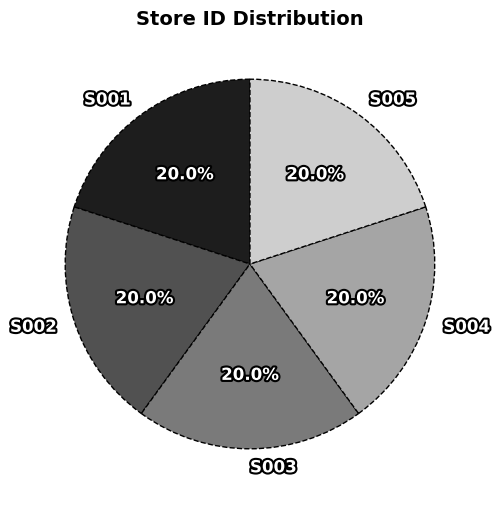

In [6]:
val_pie(df, 'Store ID')

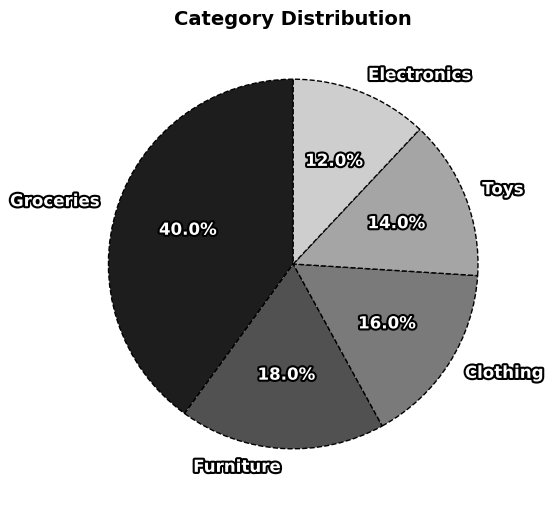

In [7]:
val_pie(df, 'Category')

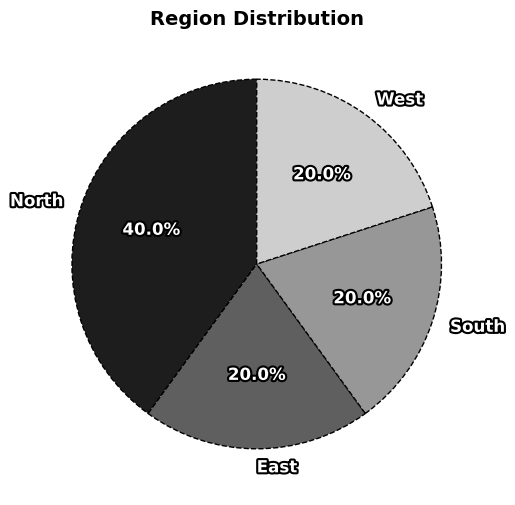

In [8]:
val_pie(df, 'Region')

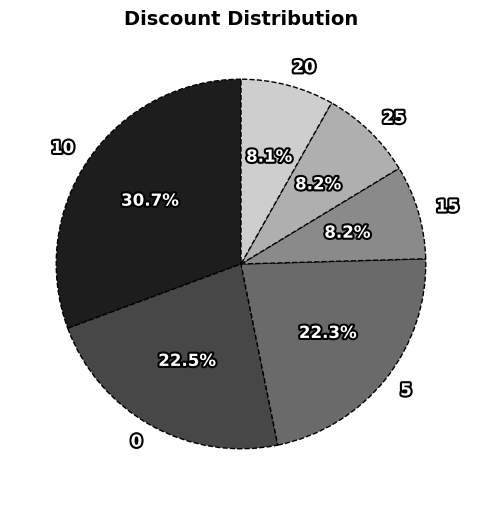

In [9]:
val_pie(df, 'Discount')

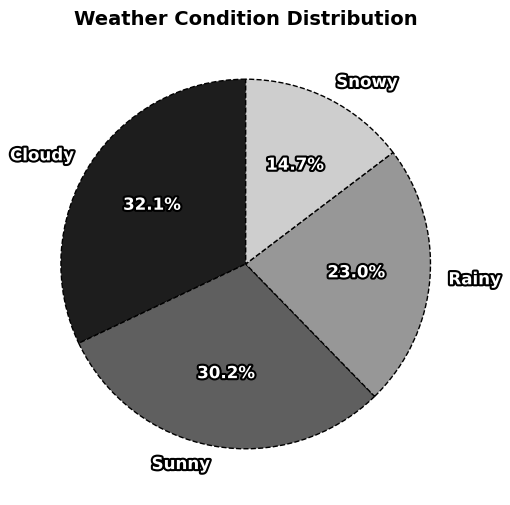

In [10]:
val_pie(df, 'Weather Condition')

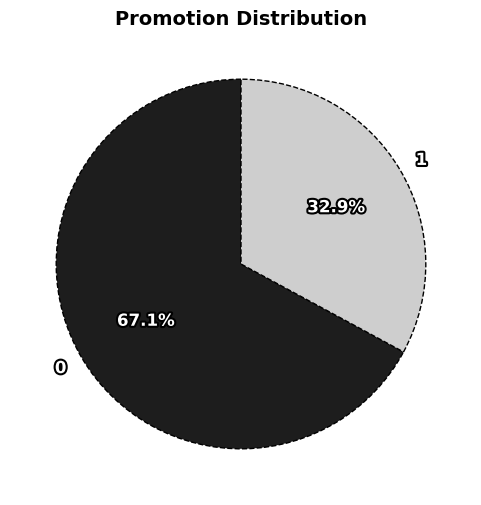

In [11]:
val_pie(df, 'Promotion')

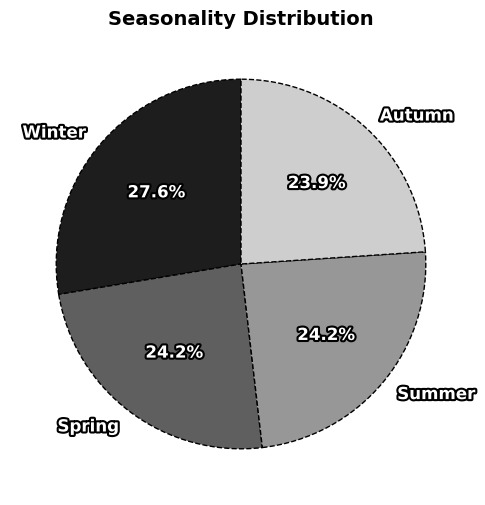

In [12]:
val_pie(df, 'Seasonality')

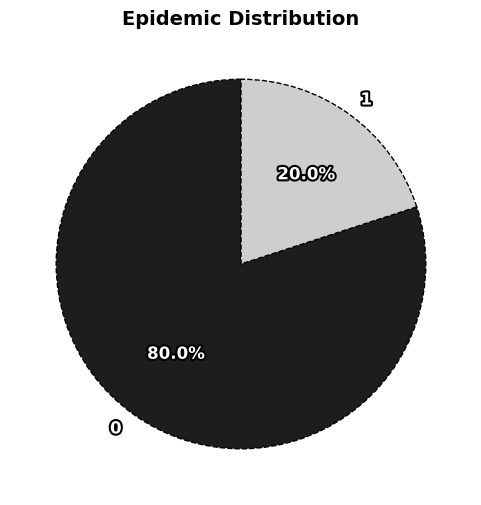

In [13]:
val_pie(df, 'Epidemic')

*From these pie charts, we’ll learn which stores see the most traffic, which product categories reign supreme, and how external factors like weather and promotional events sway demand.*

# **3. Seasonality & Temporal Patterns**
Demand in retail is rarely constant—holiday sales, weekend rushes, and seasonal fads all play their part. Here, we’ll leverage DeepRage’s <code>val_seasonality</code> to break down demand trends by year, month, and week. 

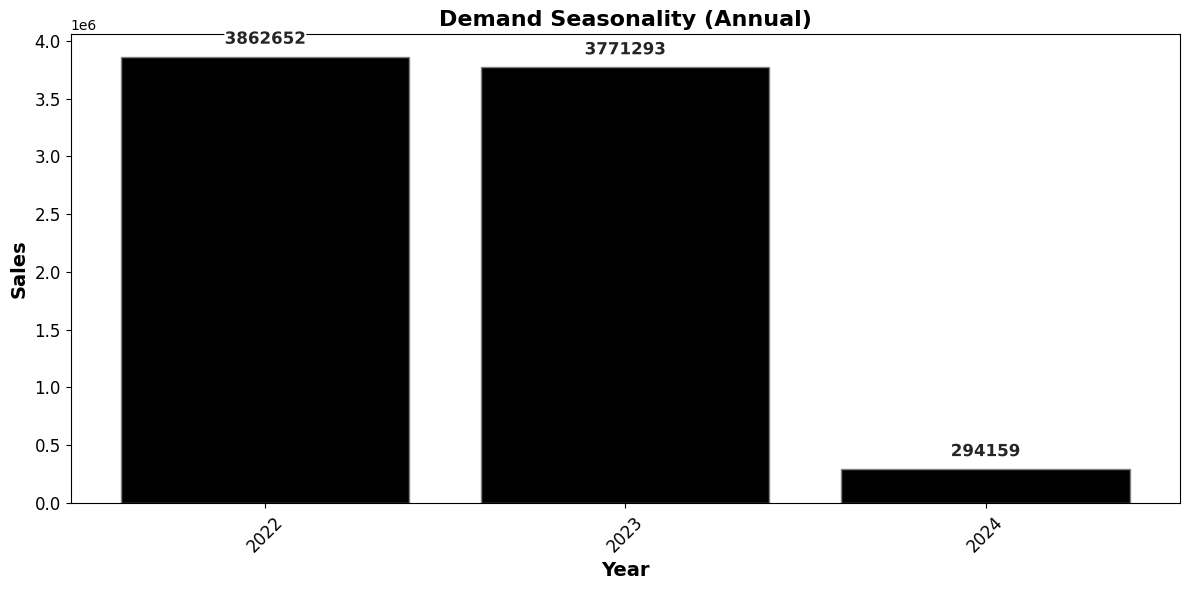

Date
2022-12-31    3862652
2023-12-31    3771293
2024-12-31     294159
Freq: YE-DEC, Name: Demand, dtype: int64

In [14]:
df['Date'] = pd.to_datetime(df['Date'])
val_seasonality(df, 'Date', 'Demand', 'Y')

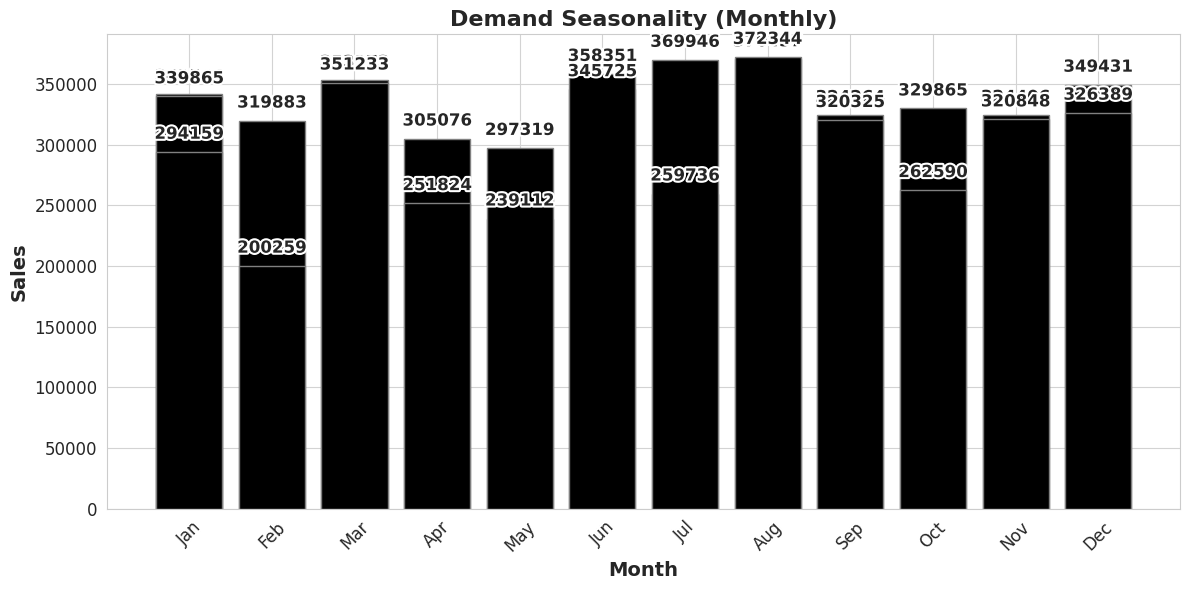

Date
2022-01-31    341544
2022-02-28    319883
2022-03-31    353173
2022-04-30    305076
2022-05-31    239112
2022-06-30    345725
2022-07-31    259736
2022-08-31    370437
2022-09-30    324264
2022-10-31    329865
2022-11-30    324406
2022-12-31    349431
2023-01-31    339865
2023-02-28    200259
2023-03-31    351233
2023-04-30    251824
2023-05-31    297319
2023-06-30    358351
2023-07-31    369946
2023-08-31    372344
2023-09-30    320325
2023-10-31    262590
2023-11-30    320848
2023-12-31    326389
2024-01-31    294159
Freq: ME, Name: Demand, dtype: int64

In [15]:
val_seasonality(df, 'Date', 'Demand', 'M')

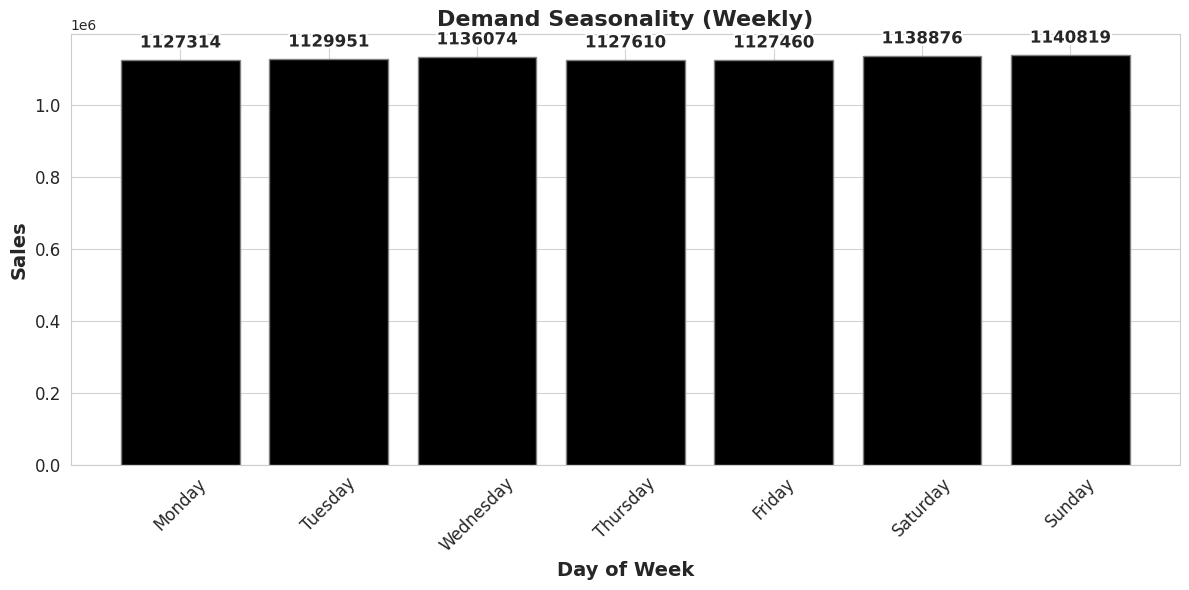

Date
Monday       1127314
Tuesday      1129951
Wednesday    1136074
Thursday     1127610
Friday       1127460
Saturday     1138876
Sunday       1140819
Name: Demand, dtype: int64

In [16]:
val_seasonality(df, 'Date', 'Demand', 'W')

*By plotting demand over yearly, monthly, and weekly frequencies, we’ll spot recurring peaks.*

# **4. Numeric Feature Distribution**
Next, let’s dive into the distributions of key numeric features: Inventory Level, Units Sold, Units Ordered, Price, Competitor Pricing, and Demand. Histograms with KDE overlays will help us understand central tendencies, outliers, and the overall shape of these distributions. 

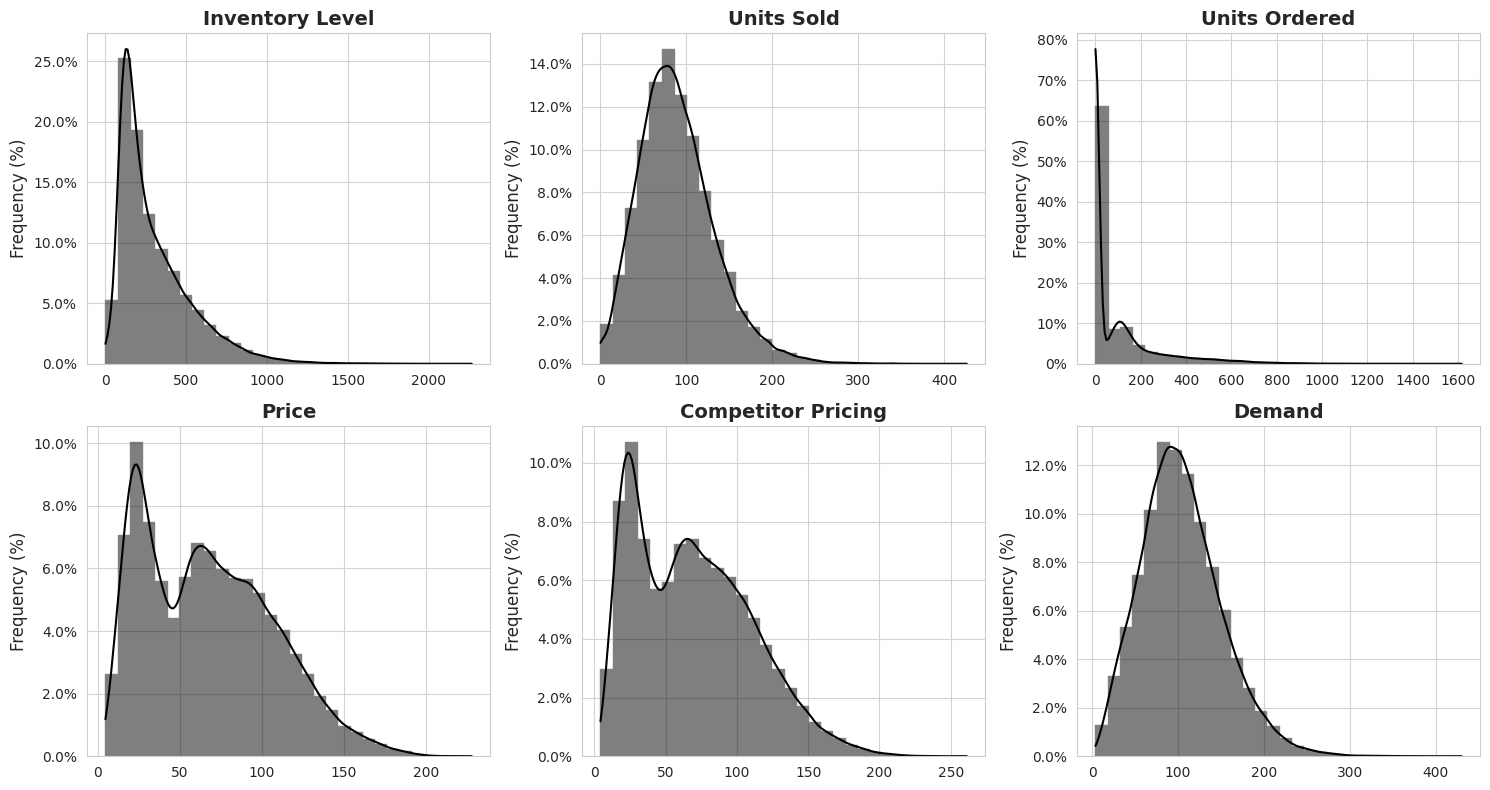

In [17]:
numeric_cols = ['Inventory Level', 'Units Sold', 'Units Ordered', 'Price', 'Competitor Pricing', 'Demand']
val_all_hist(df[numeric_cols], kde=True, freq=True)

*These plots will show us if most stores keep a consistent inventory, whether demand is skewed by a few blockbuster products, or if certain price points dominate the market. Outliers could hint at data entry errors or special promotional events.*

# **5. Feature Comparison & Correlation**
Now, let’s compare our numeric columns pairwise to uncover relationships—does a higher price correlate with lower units sold? Does competitor pricing influence our demand? DeepRage’s <code>compare_columns</code> will generate insightful scatter plots and correlation metrics.


▶ Inventory Level ↔ Units Sold   Pearson r=0.23 (p=0) ✓


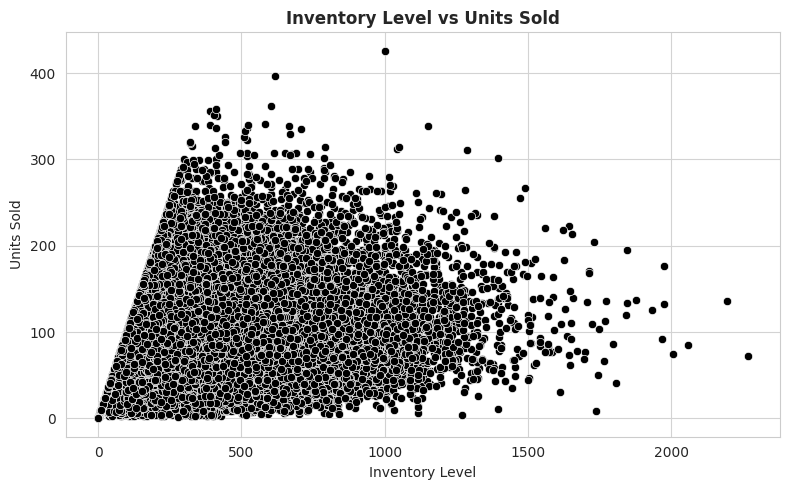


▶ Inventory Level ↔ Units Ordered   Pearson r=-0.03 (p=1.09e-21) ✓


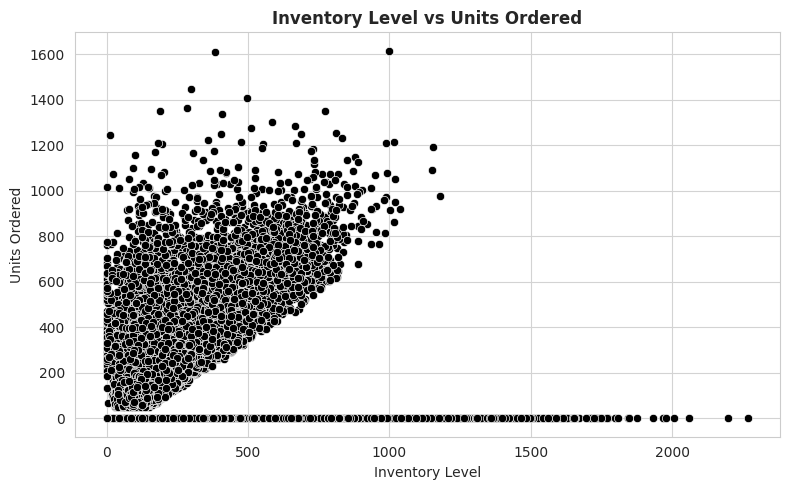


▶ Inventory Level ↔ Price   Pearson r=-0.04 (p=4.82e-24) ✓


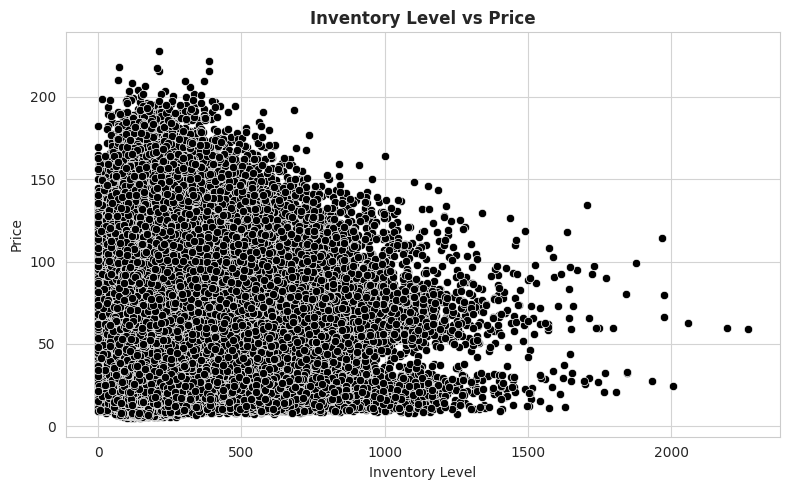


▶ Inventory Level ↔ Competitor Pricing   Pearson r=-0.03 (p=9.37e-22) ✓


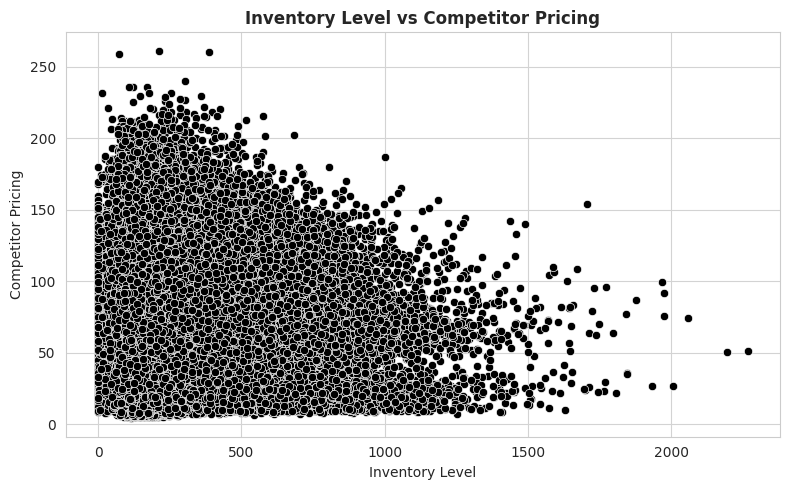


▶ Inventory Level ↔ Demand   Pearson r=0.13 (p=4.37e-269) ✓


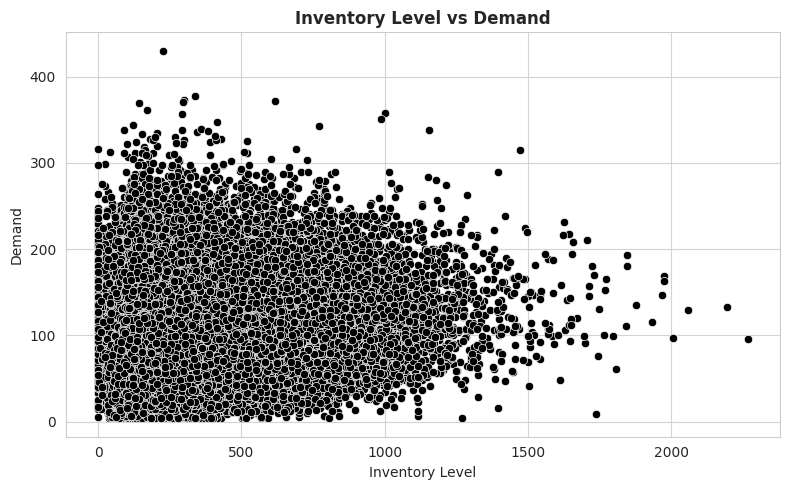


▶ Units Sold ↔ Units Ordered   Pearson r=0.43 (p=0) ✓


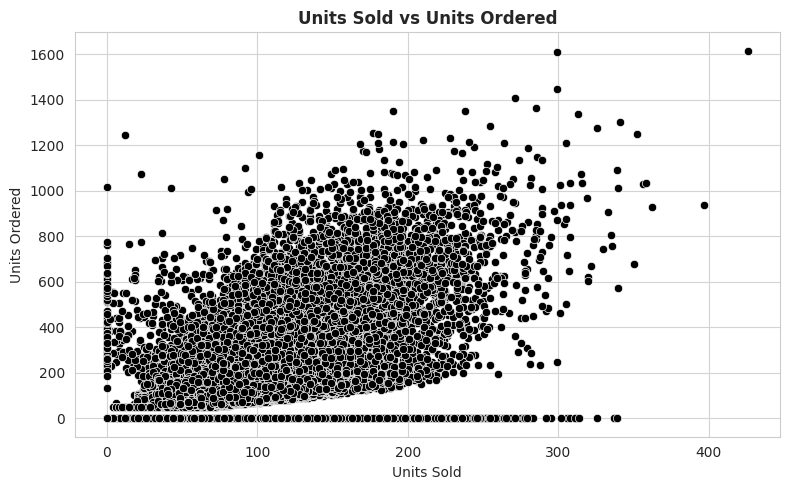


▶ Units Sold ↔ Price   Pearson r=-0.01 (p=6.35e-05) ✓


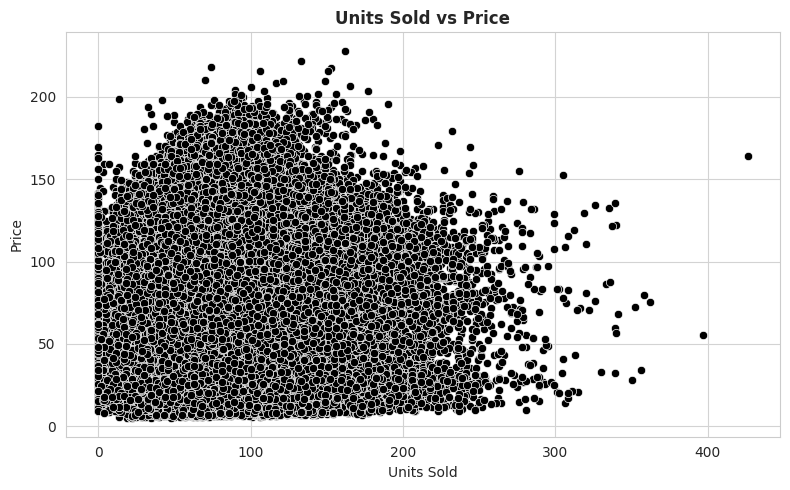


▶ Units Sold ↔ Competitor Pricing   Pearson r=-0.01 (p=0.000115) ✓


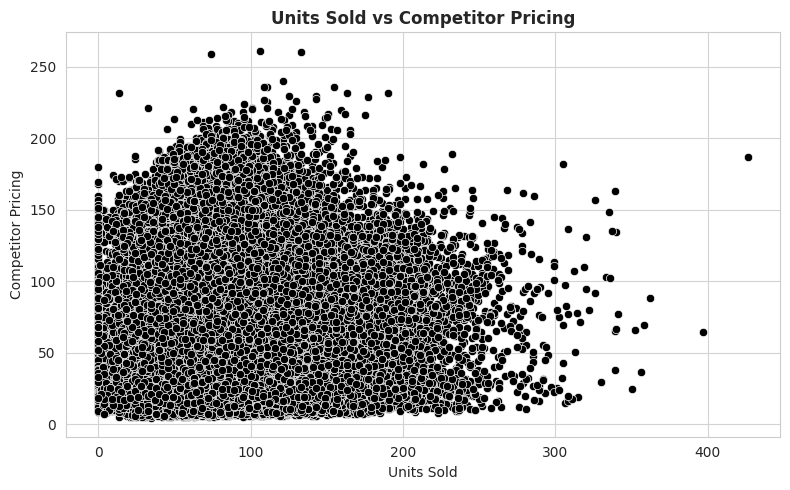


▶ Units Sold ↔ Demand   Pearson r=0.83 (p=0) ✓


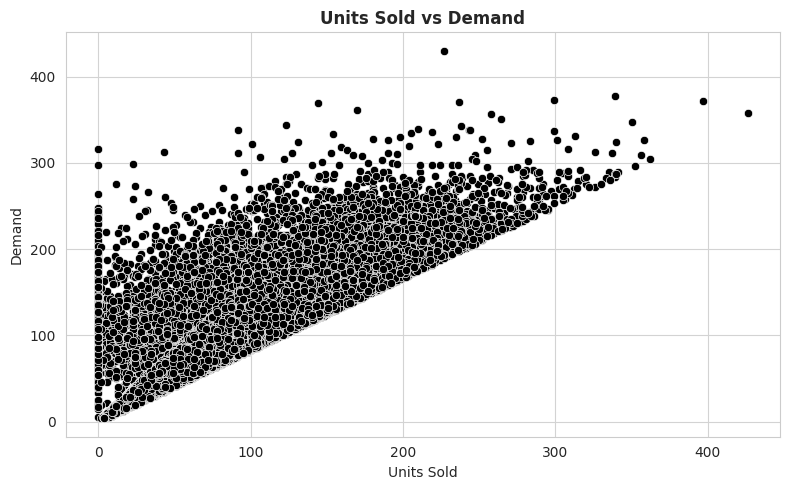


▶ Units Ordered ↔ Price   Pearson r=0.04 (p=2.42e-35) ✓


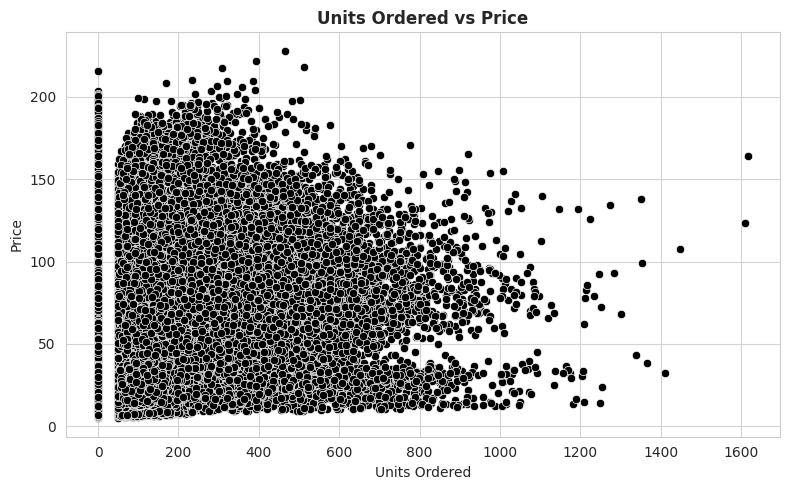


▶ Units Ordered ↔ Competitor Pricing   Pearson r=0.05 (p=1e-35) ✓


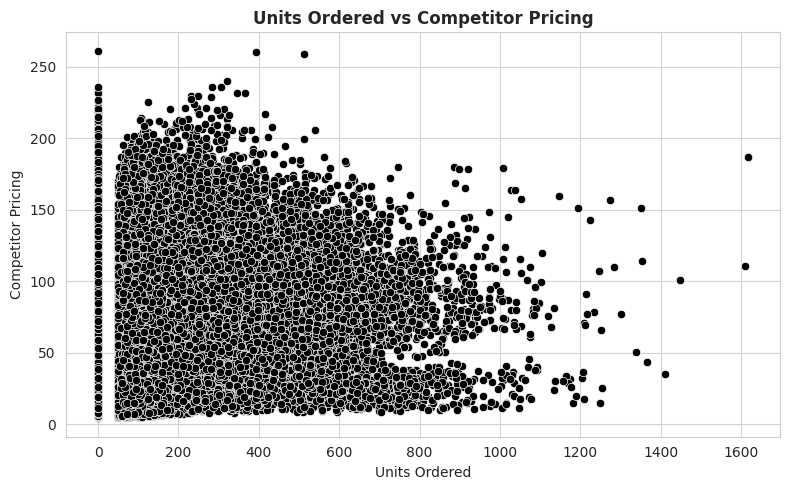


▶ Units Ordered ↔ Demand   Pearson r=0.51 (p=0) ✓


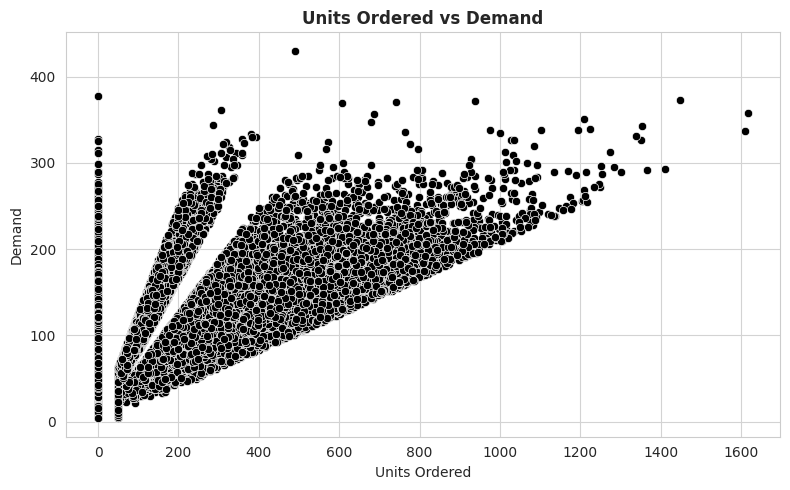


▶ Price ↔ Competitor Pricing   Pearson r=0.98 (p=0) ✓


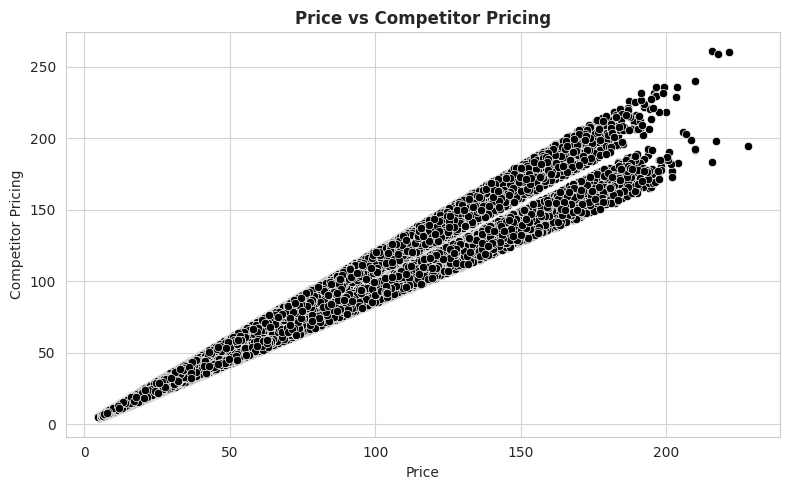


▶ Price ↔ Demand   Pearson r=-0.02 (p=9.9e-11) ✓


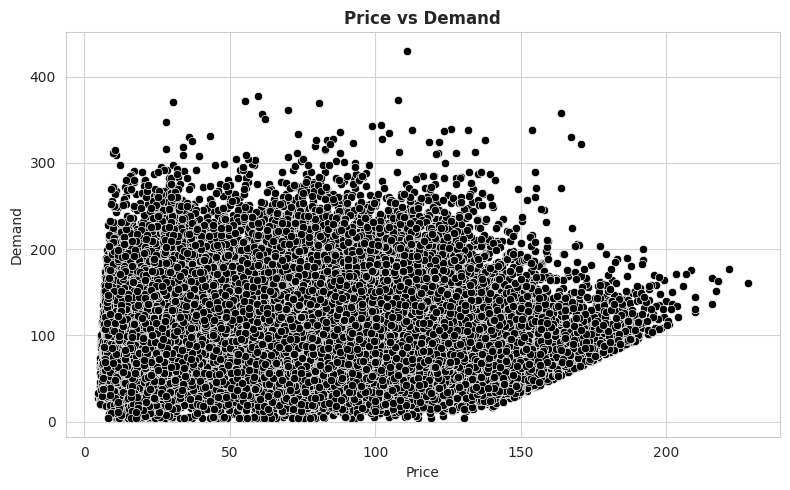


▶ Competitor Pricing ↔ Demand   Pearson r=-0.02 (p=2.13e-10) ✓


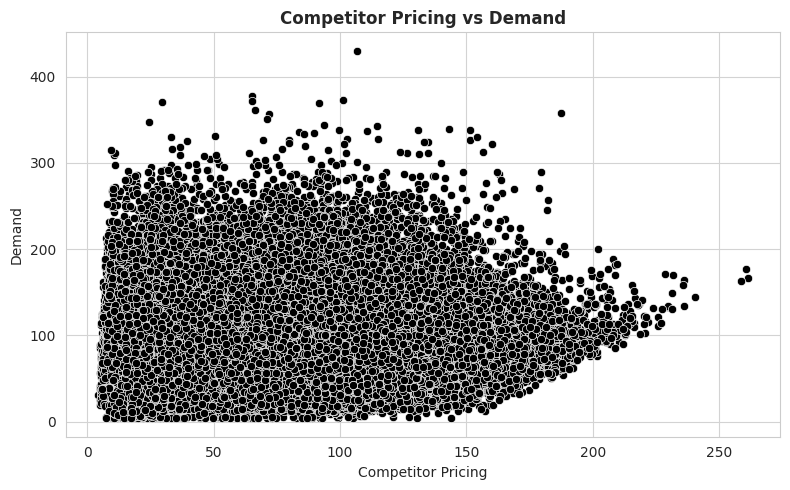

In [18]:
compare_columns(df[numeric_cols])

*Correlations close to ±1 will catch our eye—strong relationships that can guide feature engineering and model selection.*

# **6. Model Suggestion with RageReport**
Finally, we ask <strong>RageReport</strong> to propose a baseline model for predicting <strong>Category</strong>. 

In [19]:
rr = RageReport(df)
rr.propose_model('Category')

Model,Accuracy
Logistic,0.8097
Forest,1.0


<link href="https://fonts.googleapis.com/css2?family=Cinzel:wght@700&display=swap" rel="stylesheet"> <h1 style="font-family: 'Cinzel', serif; font-size: 3em; color: #8B0000; text-align: center; margin-top: 2em;"> Mission Accomplished: Data Insights Unlocked </h1> <p style="font-family: 'Roboto', sans-serif; font-size: 1.5em; color: #333; text-align: center;"> Congratulations, fellow data samurai! We’ve traversed the landscape of retail data—from initial inspection to seasonality deep dives, distribution analyses, and even an automated model proposal. Your sleuthing skills have uncovered key insights that will keep shelves stocked and customers satisfied. </p> <p style="font-family: 'Roboto', sans-serif; font-size: 1.2em; color: #555; text-align: center;"> <em>Keep these insights close as you refine your forecasting strategy—after all, in the world of retail, staying one step ahead means never running out of coffee filters. Until next time, may your predictions be sharp and your sales charts ever ascending!</em> </p>